In [18]:
from matplotlib import pyplot as plt
import numpy as np

# Estimating Temporal Response Functions (TRFs) with Time-Lagged Regression

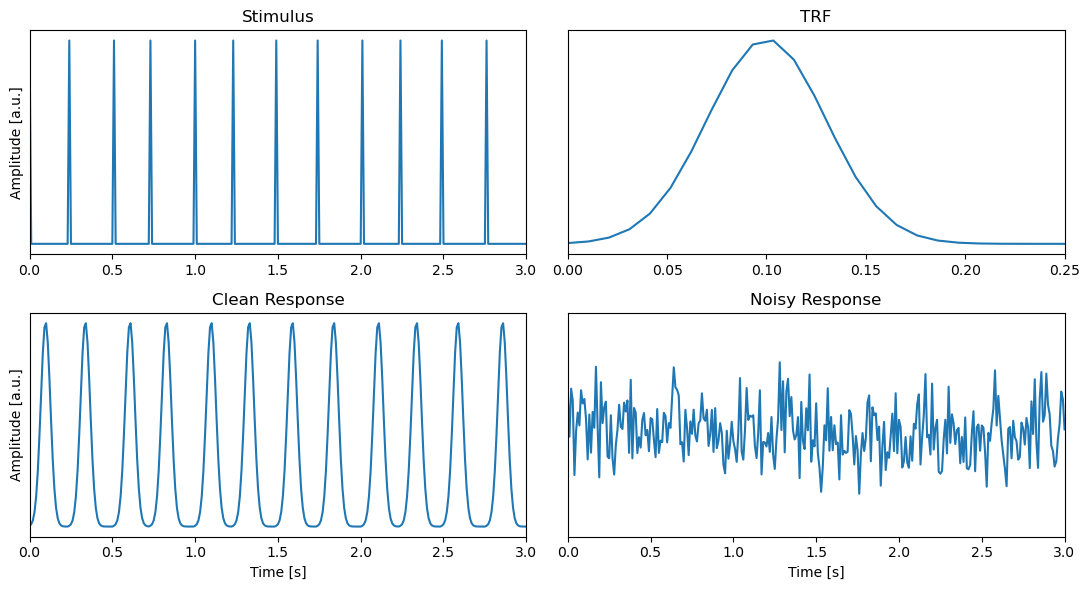

In [29]:
np.random.seed(21)
fs = 100
dur = 100
n_samples = int(dur * fs)

# Generate simple TRF from exponential function
t_trf = np.linspace(0, 0.3, int(0.3*fs))
width = 0.03
t_peak = 0.1
trf = np.exp(-((t_trf - t_peak) ** 2) / (2 * width ** 2))

# Generate impulses to represent jittered stimulus onsets
stim = np.zeros(n_samples)
isi = 0.25
jitter = 0.01
n_impulses = int(dur / isi)
times = np.arange(n_impulses) * isi
times = times + np.random.randn(n_impulses) * jitter
times = np.clip(times, 0, dur - 1/fs) 
idx = (times * fs).astype(int)
stim[idx] = 1

# Generate response and add noise
response = np.convolve(stim, trf, mode="full")[:len(stim)]
noisy_response = response + np.random.randn(len(response))
t = np.linspace(0, dur, dur*fs)

fig, ax = plt.subplots(2, 2, figsize=(11, 6))
ax = ax.flatten()
ax[0].plot(t, stim)
ax[0].set(title="Stimulus", xlim=(0,3), ylabel="Amplitude [a.u.]")
ax[1].plot(t_trf, trf)
ax[1].set(title="TRF", xlim=(0,0.25))
ax[2].plot(t, response)
ax[2].set(title="Clean Response", xlim=(0,3), ylabel="Amplitude [a.u.]", xlabel="Time [s]")
ax[3].plot(t, noisy_response)
ax[3].set(title="Noisy Response", xlim=(0,3), xlabel="Time [s]")
[a.set_yticks([]) for a in ax]
plt.tight_layout()

- The neural response to the stimulus is characterized by a temporal response function (TRF)
- We measure the noisy response and aim to recover the TRF (i.e. the response characteristics)
- This is a regression problem but with time lags!

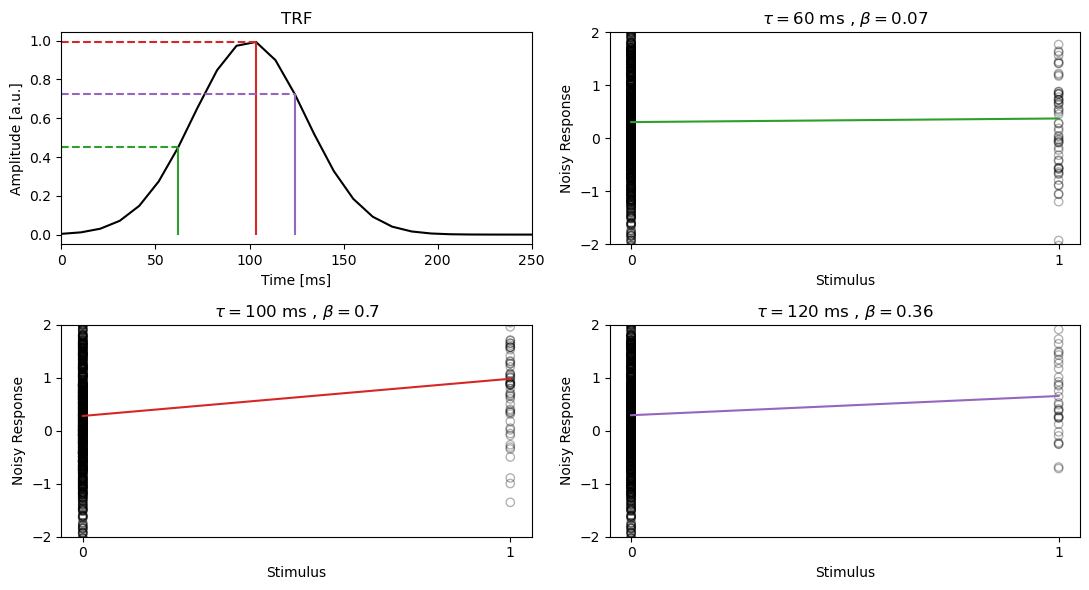

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
ax = ax.flatten()

lags = [6, 10, 12]  # Choose lags to visualize
ax[0].plot(t_trf*1000, trf, color="black")
ax[0].set(xlabel="Time [ms]", ylabel="Amplitude [a.u.]", title="TRF", xlim=(0, 250))

for i, lag in enumerate(lags):
    stim_lagged = np.roll(stim, lag)
    X = np.hstack((np.ones((len(stim_lagged), 1)), stim_lagged[:, np.newaxis]))
    y = noisy_response[:, np.newaxis]
    b = np.linalg.solve(X.T @ X, X.T @ y)
    
    # Plot using original stim_lagged, not X
    ax[i+1].scatter(stim_lagged[::10], noisy_response[::10], color="black", facecolors="none", alpha=0.3)
    ax[i+1].plot([0, 1], [b[0, 0], b[0, 0] + b[1, 0]], color=f"C{i+2}")  # intercept to intercept+slope
    ax[i+1].set(
        title=f"$\\tau={(int((lag/fs)*1000))}$ ms , $\\beta={b[1,0].round(2)}$",  # b[1,0] is the slope
        ylabel="Noisy Response",
        xlabel="Stimulus",
        xticks=[0, 1],
        ylim=(-2,2))
    ax[0].vlines(x=t_trf[lag]*1000, ymin=0, ymax=trf[lag], color=f"C{i+2}")
    ax[0].hlines(y=trf[lag], xmin=0, xmax=t_trf[lag]*1000, color=f"C{i+2}", linestyle="--")
plt.tight_layout();

- Perform linear regression between noisy response and stimulus
- Shift stimulus by time lag $\tau$
- The slope of the regression line $\beta_{\tau}$ is proportional to the TRF amplitude at $t=\tau$

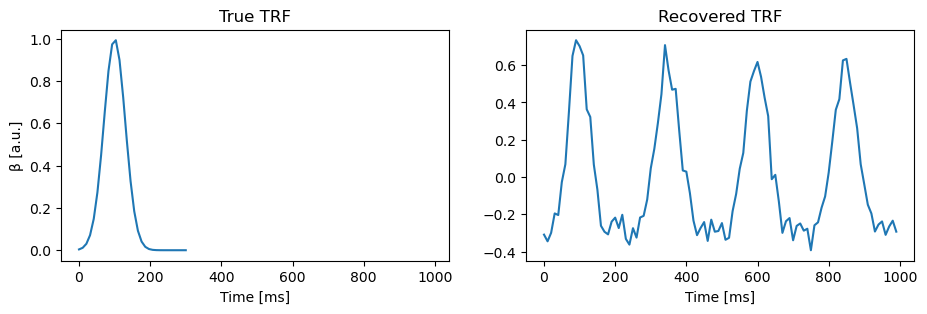

In [31]:
max_lag = 100
betas = []
for lag in range(max_lag):
    stim_lagged = np.roll(stim, lag)
    X = stim_lagged[:, np.newaxis]
    X = np.hstack((np.ones((len(X), 1)), X))
    y = noisy_response[:, np.newaxis]
    b = np.linalg.solve(X.T @ X, X.T @ y)
    betas.append(b[1, 0])

fig, ax = plt.subplots(1,2, figsize=(11,3), sharex=True)
lags = ((np.arange(max_lag)/fs)*1000).astype(int)
ax[0].plot(t_trf*1000, trf)
ax[0].set(xlabel='Time [ms]', ylabel='β [a.u.]', title='True TRF')
ax[1].plot(lags, betas)
ax[1].set(xlabel='Time [ms]', title='Recovered TRF');


- By calculating $\beta_{\tau}$ for every time lag, we recover the original TRF
- Because the stimulus is autocorrelated, the recovered TRF shows a second peak at 100 ms plus the inter-stimulus interval
- We have to consider all time lags simultaneously!

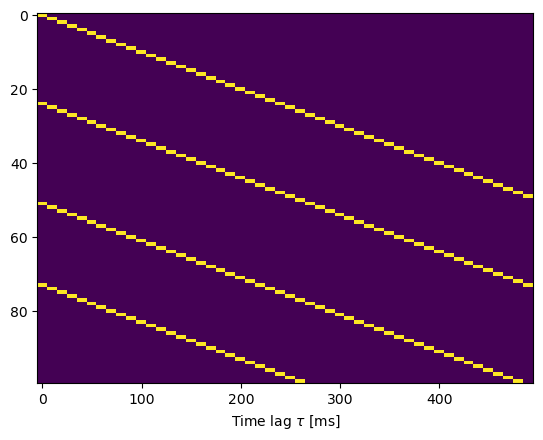

In [32]:
max_lag = 50
n = len(stim)
X_lagged = np.zeros((n, max_lag))
for lag in range(max_lag):
    X_lagged[lag:, lag] = stim[:n-lag]

X_lagged = np.column_stack([np.ones(n), X_lagged])
plt.imshow(X_lagged[:100, 1:], aspect="auto")
lags_ms = ((np.arange(max_lag) / fs) * 1000).astype(int)
plt.xticks(np.arange(0, max_lag, 10), lags_ms[::10])
plt.xlabel("Time lag $\\tau$ [ms]");

Make clear relationship between stimulus and time vector

- Create a single **design matrix** with the time-lagged features
- Each row is shifted by one sample to the right
- Calculate $\beta = (X^T X)^{-1} X^T y$, where $X$ is the design matrix

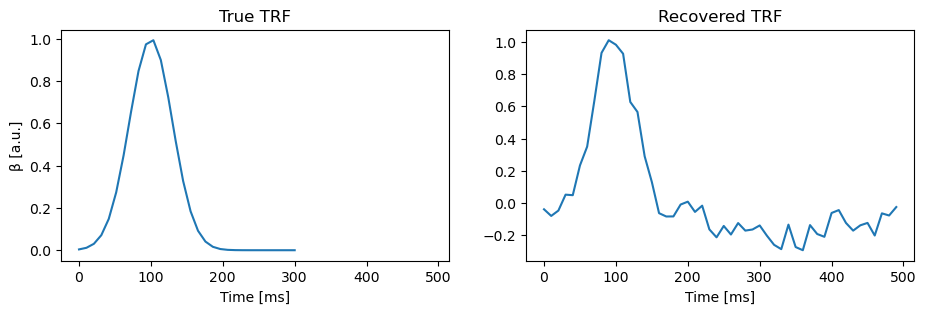

In [33]:
X = X_lagged
# Solve all lags simultaneously
betas = np.linalg.solve(X.T @ X, X.T @ y)

lags = ((np.arange(max_lag) / fs) * 1000).astype(int)
fig, ax = plt.subplots(1,2, figsize=(11,3), sharex=True)
lags = ((np.arange(max_lag)/fs)*1000).astype(int)
ax[0].plot(t_trf*1000, trf)
ax[0].set(xlabel='Time [ms]', ylabel='β [a.u.]', title='True TRF')
ax[1].plot(lags, betas[1:])
ax[1].set(xlabel='Time [ms]', title='Recovered TRF');

- Multi-lag regression prevents the spurious second peak
- This only works if the autocorrelation is not perfect (i.e. there is some jitter)!

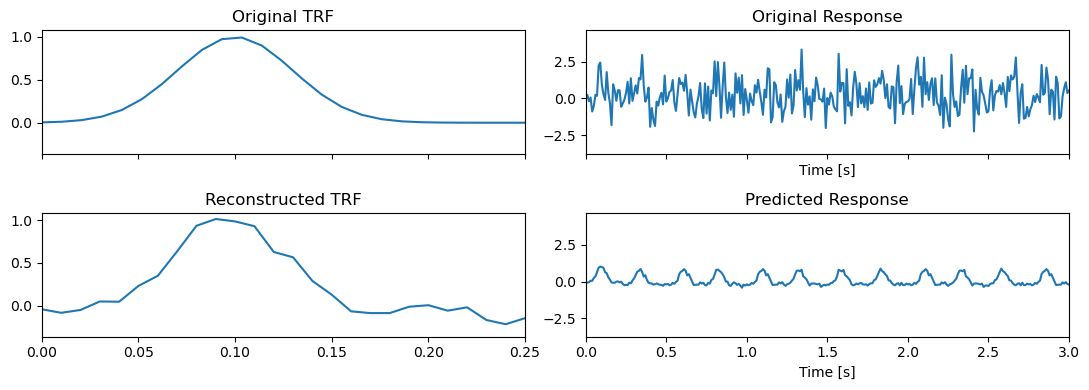

In [161]:
# Generate response and add noise
predicted_response = np.convolve(stim, betas[1:].flatten(), mode="full")[:len(stim)]
noisy_response = response + np.random.randn(len(response))
t = np.linspace(0, dur, dur*fs)

fig, ax = plt.subplots(2, 2, figsize=(11, 4), sharex="col", sharey="col")
ax = ax.flatten()
ax[0].plot(t_trf, trf)
ax[0].set(title="Original TRF", xlim=(0,0.25))
ax[1].plot(t, noisy_response)
ax[1].set(title="Original Response", xlim=(0,3), xlabel="Time [s]")
ax[2].plot(np.arange(len(betas[1:]))/fs, betas[1:])
ax[2].set(title="Reconstructed TRF", xlim=(0, 0.25))
ax[3].plot(t, predicted_response)
ax[3].set(title="Predicted Response", xlim=(0,3), xlabel="Time [s]")
plt.tight_layout()

- We can predict the response by convolving the stimulus with the **reconstructed TRF**
- Comparing the predicted response with the original (e.g. by estimating $r$, $R^2$, MSE) shows the model's accuracy